In [1]:
!pip install openai sentence-transformers faiss-cpu hf_xet 


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [1]:

with open('textSamples.txt', 'r') as file:
    text = file.read()

chunks = text.splitlines()

In [2]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(chunks)

/home/codespace/.python/current/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from sklearn.metrics.pairwise import cosine_similarity
cosine_sim = cosine_similarity(embeddings)

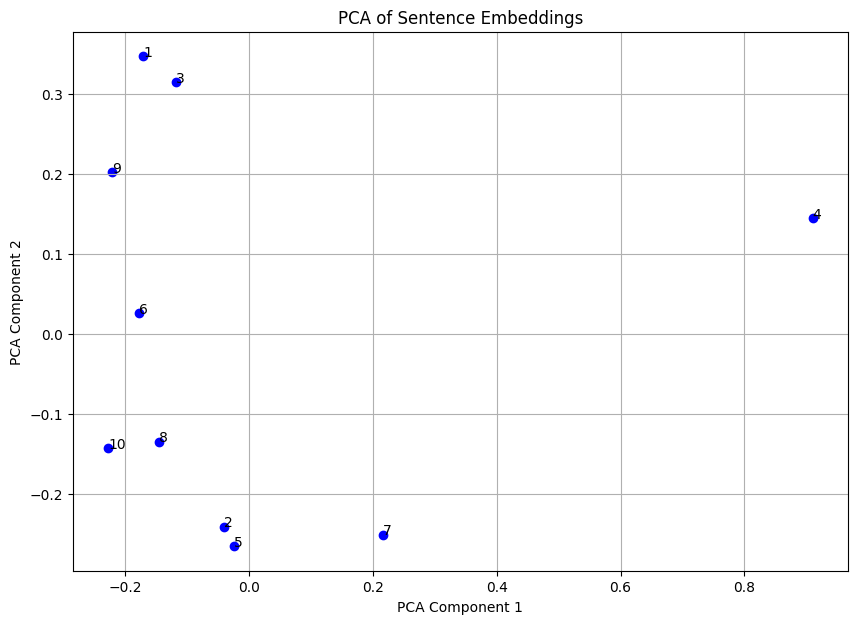

In [4]:

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


pca = PCA(n_components=2)
pca_result = pca.fit_transform(cosine_sim)
plt.figure(figsize=(10, 7))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c='blue')
for i, text in enumerate(chunks):
    plt.annotate(f"{i+1}", (pca_result[i, 0], pca_result[i, 1]))
plt.title("PCA of Sentence Embeddings")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()


/home/codespace/.local/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


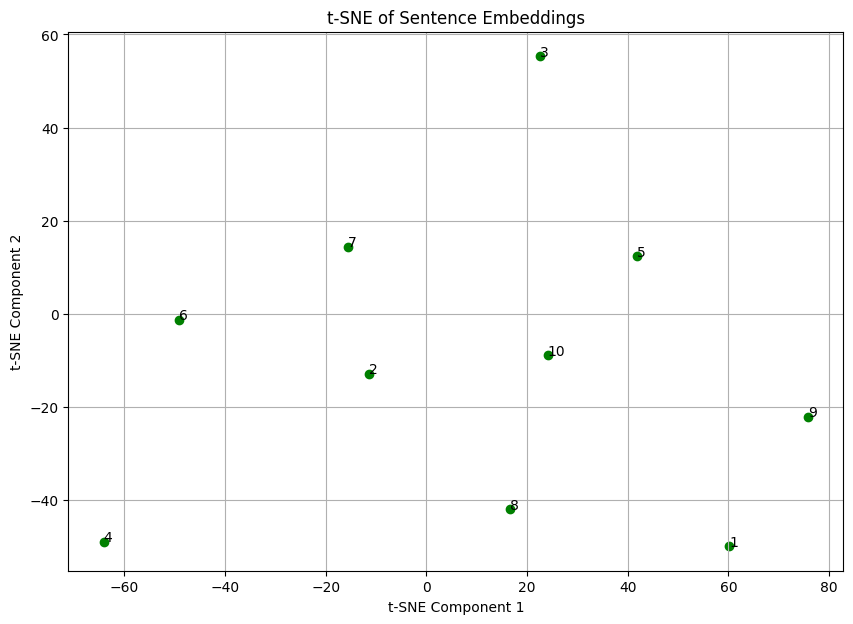

In [5]:

tsne = TSNE(n_components=2, perplexity=5, n_iter=300)
tsne_result = tsne.fit_transform(cosine_sim)
plt.figure(figsize=(10, 7))
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c='green')
for i, text in enumerate(chunks):
    plt.annotate(f"{i+1}", (tsne_result[i, 0], tsne_result[i, 1]))
plt.title("t-SNE of Sentence Embeddings")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.grid(True)
plt.show()
